In [1]:
!pip install imutils


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import imutils

In [5]:
img_org = cv2.imread('./images/test2.jpeg')

In [6]:
cv2.namedWindow('original image', cv2.WINDOW_NORMAL)
cv2.imshow('original image', img_org)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [7]:
def resize_func(image, width=590):
    h,w,c = image.shape
    height = int((h/w)* width)
    size= (width,height)
    image = cv2.resize(image,(width,height))
    return image, size
                       
    

In [8]:
img_resize, size = resize_func(img_org)
print(size)
cv2.imshow('test image', img_resize)
cv2.waitKey(0)
cv2.destroyAllWindows()

(590, 885)


In [9]:
hsv = cv2.cvtColor(img_resize, cv2.COLOR_BGR2HSV)
lower_white = np.array([0, 0, 170])
upper_white = np.array([180, 50, 255])
mask = cv2.inRange(hsv, lower_white, upper_white)
kernel_big = np.ones((20, 20), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_big)

cv2.imshow('mask', mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

for contour in contours:
    hull = cv2.convexHull(contour)
    prei = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.02 * prei, True)
    if len(approx) == 4:
        four_pts = np.squeeze(approx)
        break

cv2.drawContours(img_resize, [four_pts], -1, (0, 45, 233), 3)
multiplier = img_org.shape[1] / size[0]
four_pts = four_pts * multiplier
four_pts = four_pts.astype(int)

cv2.imshow('detected', img_resize)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
from imutils.perspective import four_point_transform

In [11]:
img_wrap = four_point_transform(img_org, four_pts)

In [12]:
cv2.imshow('wrap' ,img_wrap)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
def bill_scanner(image):
    img_resize, size = resize_func(image)
    
    hsv = cv2.cvtColor(img_resize, cv2.COLOR_BGR2HSV)
    lower_white = np.array([0, 0, 170])
    upper_white = np.array([180, 50, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)
    kernel_big = np.ones((20, 20), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_big)

    
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    for contour in contours:
        hull = cv2.convexHull(contour)
        prei = cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, 0.02 * prei, True)
        if len(approx) == 4:
            four_pts = np.squeeze(approx)
            break
    
    cv2.drawContours(img_resize, [four_pts], -1, (0, 45, 233), 3)
    multiplier = image.shape[1] / size[0]
    four_pts = four_pts * multiplier
    four_pts = four_pts.astype(int)
    
    
    
    img_wrap = four_point_transform(image, four_pts)

    return img_wrap, four_pts, img_resize, mask

In [21]:
img = cv2.imread('./images/test1.jpeg')
wp_img, pts_img, cont_img, msk_img = bill_scanner(img)

In [22]:
cv2.imshow('last3', msk_img)
cv2.imshow('last2', cont_img)
cv2.imshow('last', wp_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
def bright_cont(input_img , brightness = 0, contrast=0):
    if brightness != 0:
        if brightness> 0:
            shadow = brightness
            highlight = 255
        else:
            shadow = 0
            highlight = 255+ brightness
        alpha_b =(highlight - shadow)/ 255
        gamma_b = shadow
        buf = cv2.addWeighted(input_img, alpha_b, input_img, 0, gamma_b)
    else:
        buf = input_img.copy()
    if contrast != 0:
        f =131*(contrast+127)/(127*(131-contrast))
        alpha_c = f
        gamma_c = 127*(1-f)

        buf = cv2.addWeighted(buf, alpha_c, buf, 0, gamma_c)
        
    return buf
                               

In [50]:
rgb_img = cv2.cvtColor(wp_img, cv2.COLOR_BGR2RGB)
fixed_img_1 = bright_cont(rgb_img, 85,0)
fixed_img_2 = bright_cont(rgb_img, 0,35)

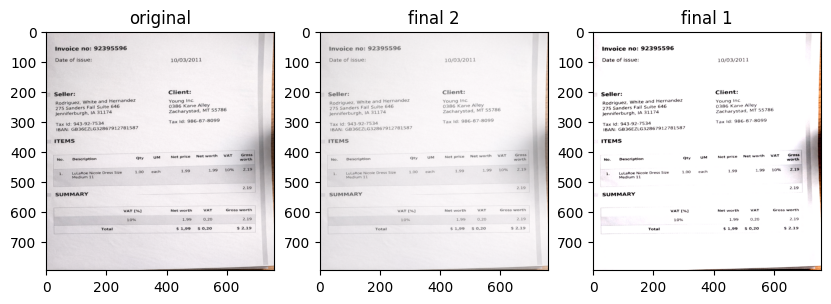

In [52]:
plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(rgb_img)
plt.title('original')

plt.subplot(1,3,2)
plt.imshow(fixed_img_1)
plt.title('final 2')

plt.subplot(1,3,3)
plt.imshow(fixed_img_2)
plt.title('final 1')

plt.show()